# Actividad 15: Data Journey, Monitoreo y Model Serving

**Objetivo:** Comprender el ciclo de vida completo de un modelo de aprendizaje profundo: preparación de datos → entrenamiento → monitoreo → puesta en operación.

**Dataset:** MNIST — 70 000 imágenes de dígitos escritos a mano (28×28 px).

**Modelo:** Red neuronal convolucional (CNN) de clasificación multiclase (10 dígitos).

**Monitoreo:** Simulación local de Weights & Biases mediante tablas, gráficas y registros organizados.

---
## 1. Data Journey

El **Data Journey** describe el ciclo de vida de los datos desde su origen hasta su uso en el modelo.


### Etapas del Data Journey

| Etapa | Descripción | Herramienta/Proceso |
|-------|-------------|---------------------|
| **Origen** | Imágenes de dígitos escritos a mano, recopiladas del NIST en 1998 | Digitalización y etiquetado manual |
| **Acceso** | Descarga automática desde los servidores de TensorFlow/Keras | `keras.datasets.mnist.load_data()` |
| **Exploración (EDA)** | Análisis de distribución de clases, forma de los datos, rango de valores | NumPy, Matplotlib |
| **Limpieza** | Sin valores nulos; normalización de píxeles | División por 255 |
| **Transformación** | Reshape, one-hot encoding de etiquetas | NumPy, Keras |
| **Partición** | 60 000 entrenamiento / 10 000 test (predefinida) | Keras split |
| **Alimentación al modelo** | Batches de 128 imágenes por paso de entrenamiento | `tf.data.Dataset` |

---
## 0. Importaciones y configuración

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time
import json
import datetime
from collections import defaultdict

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

tf.random.set_seed(42)
np.random.seed(42)

print(f'TensorFlow {tf.__version__}')
print(f'GPU disponible: {len(tf.config.list_physical_devices("GPU")) > 0}')
print(f'Fecha de ejecución: {datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')

TensorFlow 2.20.0
GPU disponible: False
Fecha de ejecución: 2026-05-23 18:55:32


---
## 2. Acceso y manipulación de datos

In [2]:
# ── 2.1 Carga del dataset ─────────────────────────────────────────────────
print('Cargando MNIST...')
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = keras.datasets.mnist.load_data()

print(f'Train: {x_train_raw.shape} imágenes, etiquetas: {y_train_raw.shape}')
print(f'Test:  {x_test_raw.shape} imágenes, etiquetas: {y_test_raw.shape}')
print(f'Tipo de dato: {x_train_raw.dtype}')
print(f'Rango de valores: [{x_train_raw.min()}, {x_train_raw.max()}]')
print(f'Clases únicas: {np.unique(y_train_raw)}')

Cargando MNIST...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (60000, 28, 28) imágenes, etiquetas: (60000,)
Test:  (10000, 28, 28) imágenes, etiquetas: (10000,)
Tipo de dato: uint8
Rango de valores: [0, 255]
Clases únicas: [0 1 2 3 4 5 6 7 8 9]


/tmp/ipykernel_13698/1838922057.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


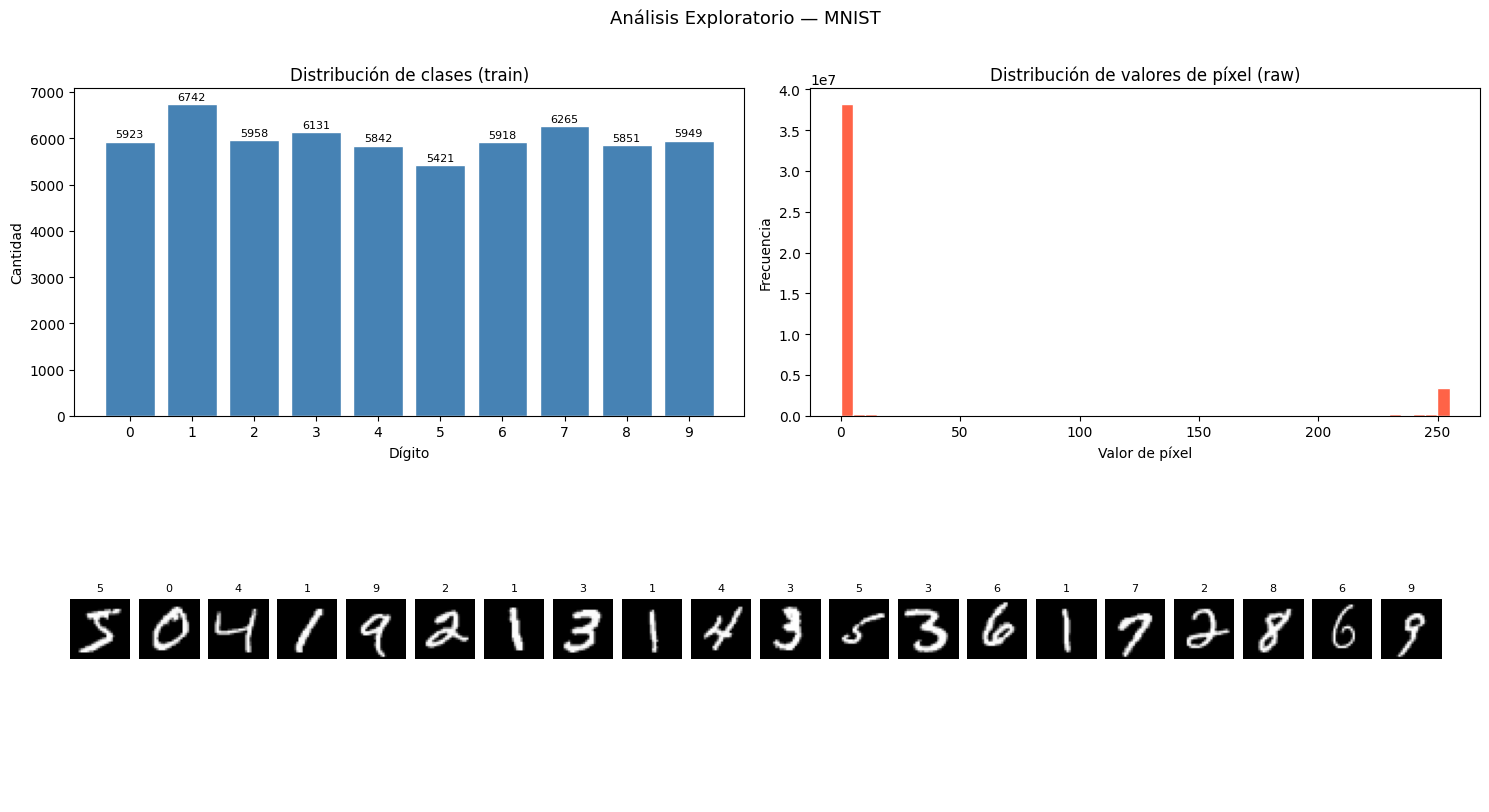


Estadísticas del dataset:
  Media de píxeles (train): 33.32
  Desv. estándar (train):   78.57
  Clase más frecuente:      1 (6742 muestras)
  Clase menos frecuente:    5 (5421 muestras)


In [3]:
# ── 2.2 Análisis exploratorio (EDA) ──────────────────────────────────────
fig = plt.figure(figsize=(15, 8))
gs  = gridspec.GridSpec(2, 2, figure=fig)

# --- Muestras por clase ---
ax1 = fig.add_subplot(gs[0, 0])
clases, conteos = np.unique(y_train_raw, return_counts=True)
ax1.bar(clases, conteos, color='steelblue', edgecolor='white')
ax1.set_xlabel('Dígito'); ax1.set_ylabel('Cantidad')
ax1.set_title('Distribución de clases (train)')
ax1.set_xticks(clases)
for c, n in zip(clases, conteos):
    ax1.text(c, n + 50, str(n), ha='center', va='bottom', fontsize=8)

# --- Histograma de valores de píxel ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(x_train_raw.flatten(), bins=50, color='tomato', edgecolor='white')
ax2.set_xlabel('Valor de píxel'); ax2.set_ylabel('Frecuencia')
ax2.set_title('Distribución de valores de píxel (raw)')

# --- Ejemplos de imágenes ---
ax3 = fig.add_subplot(gs[1, :])
ax3.axis('off')
for i in range(20):
    ax = fig.add_axes([0.05 + i * 0.046, 0.05, 0.04, 0.37])
    ax.imshow(x_train_raw[i], cmap='gray')
    ax.set_title(str(y_train_raw[i]), fontsize=8)
    ax.axis('off')

plt.suptitle('Análisis Exploratorio — MNIST', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Estadísticas básicas
print('\nEstadísticas del dataset:')
print(f'  Media de píxeles (train): {x_train_raw.mean():.2f}')
print(f'  Desv. estándar (train):   {x_train_raw.std():.2f}')
print(f'  Clase más frecuente:      {clases[np.argmax(conteos)]} ({conteos.max()} muestras)')
print(f'  Clase menos frecuente:    {clases[np.argmin(conteos)]} ({conteos.min()} muestras)')

In [4]:
# ── 2.3 Preprocesamiento ─────────────────────────────────────────────────
# Paso 1: Normalización de píxeles [0, 255] → [0, 1]
x_train = x_train_raw.astype('float32') / 255.0
x_test  = x_test_raw.astype('float32')  / 255.0

# Paso 2: Reshape → añadir dimensión de canal (28, 28) → (28, 28, 1)
x_train = np.expand_dims(x_train, axis=-1)
x_test  = np.expand_dims(x_test,  axis=-1)

# Paso 3: One-hot encoding de etiquetas  0-9 → vector de 10 elementos
y_train = keras.utils.to_categorical(y_train_raw, num_classes=10)
y_test  = keras.utils.to_categorical(y_test_raw,  num_classes=10)

# Paso 4: Separar validación del conjunto de entrenamiento (10%)
VAL_SPLIT = 0.1
n_val     = int(len(x_train) * VAL_SPLIT)
x_val, y_val         = x_train[:n_val],  y_train[:n_val]
x_train_f, y_train_f = x_train[n_val:],  y_train[n_val:]

print('Preprocesamiento completado:')
print(f'  x_train: {x_train_f.shape}, rango [{x_train_f.min():.1f}, {x_train_f.max():.1f}]')
print(f'  x_val:   {x_val.shape}')
print(f'  x_test:  {x_test.shape}')
print(f'  y_train: {y_train_f.shape}  (one-hot)')
print(f'  Ejemplo de etiqueta one-hot: {y_train_f[0]}  → dígito {y_train_f[0].argmax()}')

Preprocesamiento completado:
  x_train: (54000, 28, 28, 1), rango [0.0, 1.0]
  x_val:   (6000, 28, 28, 1)
  x_test:  (10000, 28, 28, 1)
  y_train: (54000, 10)  (one-hot)
  Ejemplo de etiqueta one-hot: [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]  → dígito 6


---
## 3. Implementación del modelo (CNN)

Se reutiliza la arquitectura CNN desarrollada en actividades anteriores del CADI, adaptada para clasificación de 10 clases.

**Arquitectura:**
```
Input (28×28×1)
  → Conv2D(32, 3×3) + ReLU + MaxPool(2×2)   → (13×13×32)
  → Conv2D(64, 3×3) + ReLU + MaxPool(2×2)   → (5×5×64)
  → Flatten → Dropout(0.3)
  → Dense(128) + ReLU
  → Dense(10) + Softmax
```

In [5]:
def construir_modelo():
    """
    CNN para clasificación de dígitos MNIST.
    Entrada: (28, 28, 1)  Salida: probabilidades para 10 clases.
    """
    modelo = keras.Sequential(name='CNN_MNIST', layers=[
        # --- Bloque convolucional 1 ---
        layers.Conv2D(32, (3, 3), activation='relu',
                      padding='same', input_shape=(28, 28, 1)),
        layers.MaxPooling2D((2, 2)),

        # --- Bloque convolucional 2 ---
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        # --- Clasificador ---
        layers.Flatten(),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax'),   # 10 clases
    ])

    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return modelo


modelo = construir_modelo()
modelo.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN_MNIST"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

---
## 4. Monitoreo y Logging

### Alternativa a Weights & Biases — Logger local

Se implementa un **ExperimentLogger** que simula las funcionalidades de W&B:
- Registro de hiperparámetros (config)
- Logging de métricas por época
- Exportación a JSON (trazabilidad)
- Visualización equivalente a los dashboards de W&B

In [6]:
class ExperimentLogger:
    """
    Logger local que simula las funcionalidades de Weights & Biases.
    Registra hiperparámetros, métricas por época y permite exportar
    el experimento a JSON para trazabilidad.
    """

    def __init__(self, nombre_experimento, config: dict):
        self.nombre    = nombre_experimento
        self.config    = config
        self.metricas  = defaultdict(list)   # {nombre_metrica: [val_e1, val_e2, ...]}
        self.inicio    = time.time()
        self.timestamp = datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        self.historial_epocas = []            # log por época
        print(f'[WandB-Local] Experimento iniciado: "{nombre_experimento}"')
        print(f'[WandB-Local] Config: {json.dumps(config, indent=2)}')

    def log(self, epoch: int, **kwargs):
        """Registra métricas de una época."""
        entrada = {'epoch': epoch, 'tiempo_s': round(time.time() - self.inicio, 1)}
        for nombre, valor in kwargs.items():
            self.metricas[nombre].append(float(valor))
            entrada[nombre] = round(float(valor), 5)
        self.historial_epocas.append(entrada)

    def resumen(self):
        """Muestra tabla resumen de todas las épocas."""
        df = pd.DataFrame(self.historial_epocas)
        print(f'\n[WandB-Local] Resumen del experimento: {self.nombre}')
        print('=' * 75)
        print(df.to_string(index=False))
        print('=' * 75)
        # Mejor época por val_accuracy
        if 'val_accuracy' in df.columns:
            mejor = df.loc[df['val_accuracy'].idxmax()]
            print(f'Mejor época: {int(mejor["epoch"])} '
                  f'| val_accuracy: {mejor["val_accuracy"]:.4f} '
                  f'| val_loss: {mejor["val_loss"]:.4f}')
        return df

    def exportar_json(self, ruta='experimento.json'):
        """Exporta el experimento completo a JSON (trazabilidad)."""
        datos = {
            'nombre': self.nombre,
            'timestamp': self.timestamp,
            'config': self.config,
            'historial': self.historial_epocas,
            'mejor_val_accuracy': max(self.metricas.get('val_accuracy', [0])),
        }
        with open(ruta, 'w') as f:
            json.dump(datos, f, indent=2)
        print(f'[WandB-Local] Experimento exportado a {ruta}')
        return datos


# ── Callback de Keras que conecta con el logger ───────────────────────────
class WandbLocalCallback(keras.callbacks.Callback):
    """Callback que registra métricas de Keras en el ExperimentLogger."""

    def __init__(self, logger: ExperimentLogger):
        super().__init__()
        self.logger = logger

    def on_epoch_end(self, epoch, logs=None):
        if logs:
            self.logger.log(
                epoch=epoch + 1,
                loss=logs.get('loss', 0),
                accuracy=logs.get('accuracy', 0),
                val_loss=logs.get('val_loss', 0),
                val_accuracy=logs.get('val_accuracy', 0),
            )


print('ExperimentLogger y WandbLocalCallback definidos correctamente.')

ExperimentLogger y WandbLocalCallback definidos correctamente.


---
## 5. Entrenamiento con monitoreo

In [7]:
# ── Hiperparámetros (equivalente a wandb.config) ───────────────────────
CONFIG = {
    'modelo':         'CNN_MNIST',
    'dataset':        'MNIST',
    'epocas':         15,
    'batch_size':     128,
    'learning_rate':  1e-3,
    'optimizador':    'Adam',
    'loss':           'categorical_crossentropy',
    'dropout':        0.3,
    'val_split':      0.1,
    'n_train':        len(x_train_f),
    'n_val':          len(x_val),
    'n_test':         len(x_test),
}

# ── Iniciar logger ────────────────────────────────────────────────────
logger = ExperimentLogger('CNN_MNIST_v1', CONFIG)

# ── Callbacks ─────────────────────────────────────────────────────────
callbacks = [
    WandbLocalCallback(logger),
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=3,
        restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=2,
        verbose=1, min_lr=1e-6),
]

# ── Entrenamiento ─────────────────────────────────────────────────────
print('\nIniciando entrenamiento...')
t0 = time.time()

history = modelo.fit(
    x_train_f, y_train_f,
    epochs=CONFIG['epocas'],
    batch_size=CONFIG['batch_size'],
    validation_data=(x_val, y_val),
    callbacks=callbacks,
    verbose=1
)

t_total = time.time() - t0
print(f'\nEntrenamiento completado en {t_total:.1f}s')

[WandB-Local] Experimento iniciado: "CNN_MNIST_v1"
[WandB-Local] Config: {
  "modelo": "CNN_MNIST",
  "dataset": "MNIST",
  "epocas": 15,
  "batch_size": 128,
  "learning_rate": 0.001,
  "optimizador": "Adam",
  "loss": "categorical_crossentropy",
  "dropout": 0.3,
  "val_split": 0.1,
  "n_train": 54000,
  "n_val": 6000,
  "n_test": 10000
}

Iniciando entrenamiento...
Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 92ms/step - accuracy: 0.9348 - loss: 0.2149 - val_accuracy: 0.9783 - val_loss: 0.0702 - learning_rate: 0.0010
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 35s 84ms/step - accuracy: 0.9801 - loss: 0.0649 - val_accuracy: 0.9847 - val_loss: 0.0460 - learning_rate: 0.0010
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 36s 86ms/step - accuracy: 0.9849 - loss: 0.0476 - val_accuracy: 0.9880 - val_loss: 0.0412 - learning_rate: 0.0010
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 36s 85ms/step - accuracy: 0.9884 - loss: 0.0370 - val_accuracy: 0.9895 - val_loss: 0.0352 - learning_rate: 0.0010
Epoch 5/15
42

---
## 5. Análisis de métricas

In [8]:
# ── Tabla de métricas por época (equivalente a W&B Runs Table) ────────
df_metricas = logger.resumen()

# ── Exportar a JSON ───────────────────────────────────────────────────
datos_exp = logger.exportar_json('experimento_cnn_mnist.json')


[WandB-Local] Resumen del experimento: CNN_MNIST_v1
 epoch  tiempo_s    loss  accuracy  val_loss  val_accuracy
     1      41.5 0.21485   0.93480   0.07020       0.97833
     2      77.0 0.06487   0.98015   0.04596       0.98467
     3     113.5 0.04762   0.98487   0.04120       0.98800
     4     149.4 0.03699   0.98844   0.03517       0.98950
     5     191.1 0.03005   0.99065   0.03255       0.99000
     6     226.8 0.02512   0.99181   0.03921       0.98850
     7     263.1 0.02200   0.99302   0.03190       0.99133
     8     303.7 0.01940   0.99391   0.03221       0.99100
     9     340.0 0.01699   0.99411   0.03443       0.98917
    10     376.1 0.01091   0.99644   0.02852       0.99267
    11     416.6 0.00900   0.99702   0.02768       0.99233
    12     453.4 0.00823   0.99731   0.02883       0.99217
    13     493.7 0.00702   0.99754   0.02699       0.99233
Mejor época: 10 | val_accuracy: 0.9927 | val_loss: 0.0285
[WandB-Local] Experimento exportado a experimento_cnn_mnist.jso

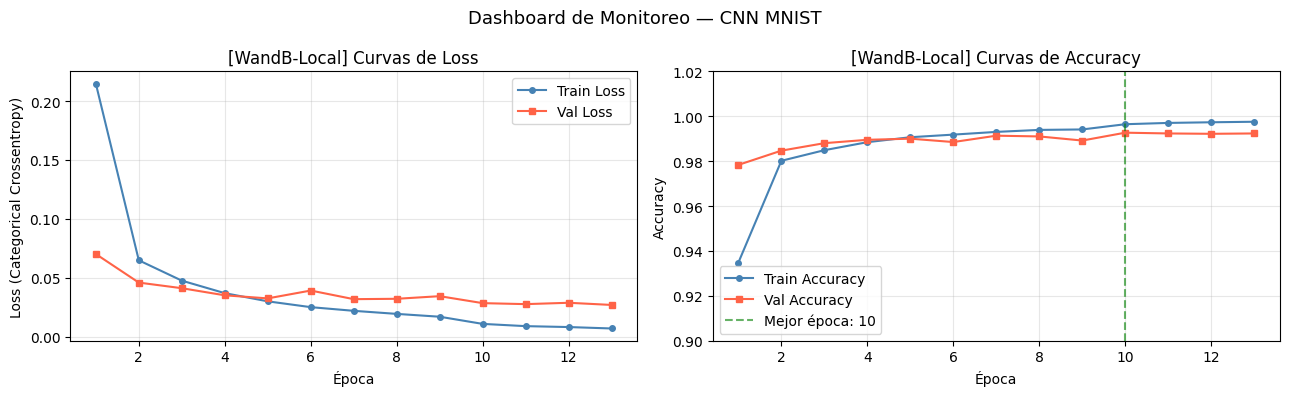

Mejor val_accuracy: 0.9927 en época 10


In [9]:
# ── Dashboard de métricas (equivalente al panel de W&B) ───────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

epocas = df_metricas['epoch'].tolist()

# --- Curvas de loss ---
axes[0].plot(epocas, df_metricas['loss'],     label='Train Loss',
             color='steelblue',  marker='o', markersize=4)
axes[0].plot(epocas, df_metricas['val_loss'], label='Val Loss',
             color='tomato', marker='s', markersize=4)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss (Categorical Crossentropy)')
axes[0].set_title('[WandB-Local] Curvas de Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Curvas de accuracy ---
axes[1].plot(epocas, df_metricas['accuracy'],     label='Train Accuracy',
             color='steelblue', marker='o', markersize=4)
axes[1].plot(epocas, df_metricas['val_accuracy'], label='Val Accuracy',
             color='tomato', marker='s', markersize=4)
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('[WandB-Local] Curvas de Accuracy')
axes[1].set_ylim([0.9, 1.02])
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Marcar mejor época
mejor_idx = df_metricas['val_accuracy'].idxmax()
mejor_ep  = df_metricas.loc[mejor_idx, 'epoch']
mejor_acc = df_metricas.loc[mejor_idx, 'val_accuracy']
axes[1].axvline(x=mejor_ep, color='green', linestyle='--', alpha=0.6,
                label=f'Mejor época: {mejor_ep}')
axes[1].legend()

plt.suptitle('Dashboard de Monitoreo — CNN MNIST', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Mejor val_accuracy: {mejor_acc:.4f} en época {mejor_ep}')

In [10]:
# ── Evaluación final en test set ──────────────────────────────────────
loss_test, acc_test = modelo.evaluate(x_test, y_test, verbose=0)

print('\n' + '='*55)
print('  EVALUACIÓN FINAL — Test Set')
print('='*55)
print(f'  Loss (test):     {loss_test:.4f}')
print(f'  Accuracy (test): {acc_test:.4f}  ({acc_test*100:.2f}%)')
print('='*55)

# Predicciones
y_pred_prob  = modelo.predict(x_test, verbose=0)
y_pred_clase = y_pred_prob.argmax(axis=1)
y_true_clase = y_test_raw

# Reporte por clase
print('\nReporte de clasificación por dígito:')
print(classification_report(y_true_clase, y_pred_clase,
                             target_names=[str(i) for i in range(10)]))


  EVALUACIÓN FINAL — Test Set
  Loss (test):     0.0241
  Accuracy (test): 0.9928  (99.28%)

Reporte de clasificación por dígito:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       0.99      1.00      1.00      1135
           2       0.99      1.00      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       1.00      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



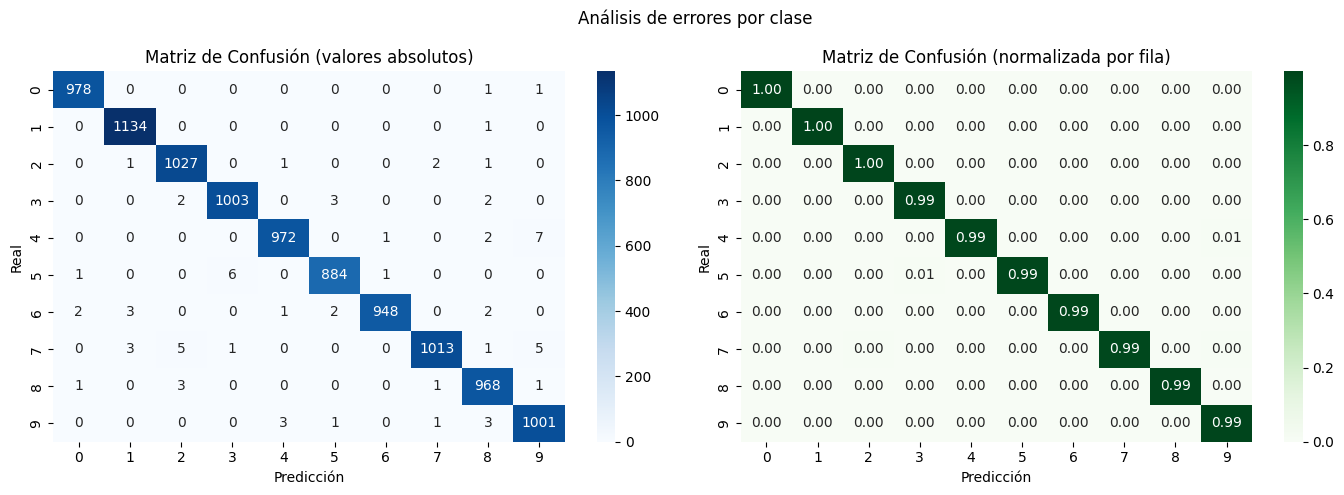

In [11]:
# ── Matriz de confusión ───────────────────────────────────────────────
cm = confusion_matrix(y_true_clase, y_pred_clase)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz absoluta
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10), ax=axes[0])
axes[0].set_xlabel('Predicción'); axes[0].set_ylabel('Real')
axes[0].set_title('Matriz de Confusión (valores absolutos)')

# Matriz normalizada
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=range(10), yticklabels=range(10), ax=axes[1])
axes[1].set_xlabel('Predicción'); axes[1].set_ylabel('Real')
axes[1].set_title('Matriz de Confusión (normalizada por fila)')

plt.suptitle('Análisis de errores por clase', fontsize=12)
plt.tight_layout()
plt.show()

Total de errores en test: 72 de 10000 (0.72%)


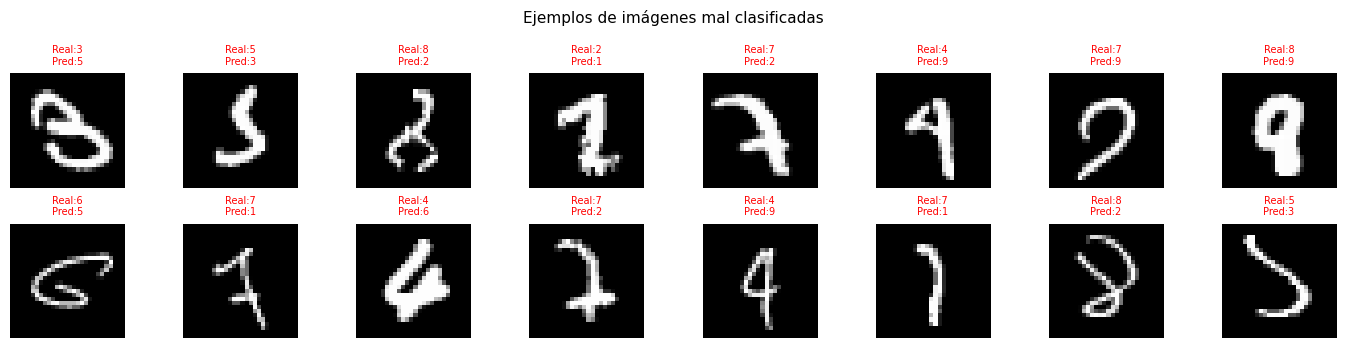

In [12]:
# ── Visualizar errores del modelo ────────────────────────────────────
errores_idx = np.where(y_pred_clase != y_true_clase)[0]
print(f'Total de errores en test: {len(errores_idx)} de {len(y_true_clase)} '
      f'({len(errores_idx)/len(y_true_clase)*100:.2f}%)')

# Mostrar 16 imágenes mal clasificadas
n_mostrar = min(16, len(errores_idx))
fig, axes = plt.subplots(2, 8, figsize=(14, 3.5))
for i, ax in enumerate(axes.flat):
    idx = errores_idx[i]
    ax.imshow(x_test_raw[idx], cmap='gray')
    ax.set_title(f'Real:{y_true_clase[idx]}\nPred:{y_pred_clase[idx]}',
                 fontsize=7,
                 color='red' if y_true_clase[idx] != y_pred_clase[idx] else 'green')
    ax.axis('off')

plt.suptitle('Ejemplos de imágenes mal clasificadas', fontsize=11)
plt.tight_layout()
plt.show()

In [13]:
# ── Interpretación del monitoreo ─────────────────────────────────────
print('ANÁLISIS DE MÉTRICAS DE MONITOREO')
print('='*60)

# Diferencia entre train y val (detectar overfitting)
ultima_epoch = df_metricas.iloc[-1]
gap_acc  = ultima_epoch['accuracy']  - ultima_epoch['val_accuracy']
gap_loss = ultima_epoch['val_loss']  - ultima_epoch['loss']

print(f'\nÚltima época entrenada: {int(ultima_epoch["epoch"])}')
print(f'  Train Loss:    {ultima_epoch["loss"]:.4f}')
print(f'  Val   Loss:    {ultima_epoch["val_loss"]:.4f}')
print(f'  Gap de Loss:   {gap_loss:+.4f}', end='')
print(' ← posible overfitting' if gap_loss > 0.02 else ' ← sin overfitting significativo')

print(f'\n  Train Accuracy: {ultima_epoch["accuracy"]:.4f}')
print(f'  Val   Accuracy: {ultima_epoch["val_accuracy"]:.4f}')
print(f'  Gap de Accuracy:{gap_acc:+.4f}', end='')
print(' ← posible overfitting' if gap_acc > 0.02 else ' ← generalización correcta')

print(f'\nTest Accuracy final: {acc_test:.4f} ({acc_test*100:.2f}%)')
print('='*60)

# Qué aporta el monitoreo
print('''
¿Qué información aporta el monitoreo?

1. DETECCIÓN TEMPRANA DE OVERFITTING
   El gap entre train_loss y val_loss indica si el modelo está
   memorizando en lugar de generalizar. EarlyStopping actúa
   automáticamente cuando val_accuracy deja de mejorar.

2. AJUSTE DE LEARNING RATE
   ReduceLROnPlateau observa val_loss y reduce el LR cuando
   el modelo se estanca, permitiendo convergencia más fina.

3. TRAZABILIDAD
   El JSON exportado guarda hiperparámetros + métricas completas,
   permitiendo comparar experimentos futuros (equivalente a
   wandb.init() + wandb.log() + wandb.finish()).

4. DIAGNÓSTICO DE CLASES
   La matriz de confusión revela qué dígitos se confunden entre
   sí (p. ej., 4↔9, 3↔5), orientando mejoras en el preprocesamiento
   o en la arquitectura del modelo.
''')

ANÁLISIS DE MÉTRICAS DE MONITOREO

Última época entrenada: 13
  Train Loss:    0.0070
  Val   Loss:    0.0270
  Gap de Loss:   +0.0200 ← sin overfitting significativo

  Train Accuracy: 0.9975
  Val   Accuracy: 0.9923
  Gap de Accuracy:+0.0052 ← generalización correcta

Test Accuracy final: 0.9928 (99.28%)

¿Qué información aporta el monitoreo?

1. DETECCIÓN TEMPRANA DE OVERFITTING
   El gap entre train_loss y val_loss indica si el modelo está
   memorizando en lugar de generalizar. EarlyStopping actúa
   automáticamente cuando val_accuracy deja de mejorar.

2. AJUSTE DE LEARNING RATE
   ReduceLROnPlateau observa val_loss y reduce el LR cuando
   el modelo se estanca, permitiendo convergencia más fina.

3. TRAZABILIDAD
   El JSON exportado guarda hiperparámetros + métricas completas,
   permitiendo comparar experimentos futuros (equivalente a
   wandb.init() + wandb.log() + wandb.finish()).

4. DIAGNÓSTICO DE CLASES
   La matriz de confusión revela qué dígitos se confunden entre
   sí 

---
## 6. Aproximación a Model Serving

El **Model Serving** es el proceso de poner un modelo entrenado a disposición de usuarios o sistemas en producción para realizar predicciones en tiempo real o en lote.

### 6.1 Guardar el modelo entrenado

In [16]:
# ── Guardar modelo en formato Keras nativo ────────────────────────────
RUTA_MODELO = 'modelo_cnn_mnist.keras'
modelo.save(RUTA_MODELO)
print(f'Modelo guardado en: {RUTA_MODELO}')

# ── Verificar que se puede cargar y hacer predicciones ────────────────
modelo_cargado = keras.models.load_model(RUTA_MODELO)

# Predicción de ejemplo
muestra = x_test[0:1]
pred    = modelo_cargado.predict(muestra, verbose=0)
print(f'\nPredicción de prueba:')
print(f'  Imagen real:     dígito {y_test_raw[0]}')
print(f'  Predicción:      dígito {pred.argmax()}')
print(f'  Confianza:       {pred.max()*100:.2f}%')
print(f'  Probabilidades:  {[f"{p:.3f}" for p in pred[0]]}')

Modelo guardado en: modelo_cnn_mnist.keras

Predicción de prueba:
  Imagen real:     dígito 7
  Predicción:      dígito 7
  Confianza:       100.00%
  Probabilidades:  ['0.000', '0.000', '0.000', '0.000', '0.000', '0.000', '0.000', '1.000', '0.000', '0.000']


In [17]:
# ── 6.2 Simulación de API REST de inferencia ─────────────────────────

def preprocesar_imagen(imagen_raw: np.ndarray) -> np.ndarray:
    """
    Preprocesa una imagen cruda para inferencia.
    Equivale al /preprocess endpoint de una API.
    """
    img = imagen_raw.astype('float32') / 255.0
    img = np.expand_dims(img, axis=-1)   # canal
    img = np.expand_dims(img, axis=0)    # batch dimension
    return img


def predecir(imagen_raw: np.ndarray, modelo_cargado) -> dict:
    """
    Simula el endpoint POST /predict de una API REST.

    Entrada:  imagen cruda (28×28, uint8)
    Salida:   JSON con predicción y confianza

    En producción esto sería el handler de FastAPI/Flask:
      @app.post('/predict')
      async def predict(imagen: UploadFile):
          img = preprocesar_imagen(await imagen.read())
          return predecir(img, modelo)
    """
    img_proc = preprocesar_imagen(imagen_raw)
    probs    = modelo_cargado.predict(img_proc, verbose=0)[0]
    clase    = int(probs.argmax())
    confianza = float(probs.max())

    return {
        'prediccion': clase,
        'confianza': round(confianza, 4),
        'probabilidades': {str(i): round(float(p), 4) for i, p in enumerate(probs)},
        'status': 'ok'
    }


# ── Simulación de 5 peticiones a la API ──────────────────────────────
print('Simulación de peticiones al endpoint POST /predict')
print('='*60)
for i in range(5):
    resultado = predecir(x_test_raw[i], modelo_cargado)
    print(f'Petición {i+1}: '
          f'Real={y_test_raw[i]} | '
          f'Predicción={resultado["prediccion"]} | '
          f'Confianza={resultado["confianza"]*100:.1f}% | '
          f'Correcto={"✓" if resultado["prediccion"]==y_test_raw[i] else "✗"}')
print('='*60)

Simulación de peticiones al endpoint POST /predict
Petición 1: Real=7 | Predicción=7 | Confianza=100.0% | Correcto=✓
Petición 2: Real=2 | Predicción=2 | Confianza=100.0% | Correcto=✓
Petición 3: Real=1 | Predicción=1 | Confianza=100.0% | Correcto=✓
Petición 4: Real=0 | Predicción=0 | Confianza=100.0% | Correcto=✓
Petición 5: Real=4 | Predicción=4 | Confianza=100.0% | Correcto=✓


In [18]:
# ── 6.3 Comparación de estrategias de Model Serving ──────────────────

estrategias = {
    'Estrategia': [
        'API REST (FastAPI)',
        'TensorFlow Serving',
        'Google Cloud AI Platform',
        'AWS SageMaker',
        'Contenedor Docker',
    ],
    'Tipo': [
        'Microservicio Python',
        'Servidor especializado TF',
        'Servicio gestionado GCP',
        'Servicio gestionado AWS',
        'Imagen autocontenida',
    ],
    'Latencia': ['Baja','Muy baja','Baja','Baja','Variable'],
    'Escalabilidad': ['Media','Alta','Muy alta','Muy alta','Alta'],
    'Complejidad': ['Baja','Media','Baja','Baja','Media'],
    'Costo': ['Gratis','Gratis/Propio','Pago','Pago','Gratis/Propio'],
    'Recomendado para': [
        'Prototipos y MVPs',
        'Producción TF a escala',
        'Entornos Google Cloud',
        'Entornos AWS',
        'Portabilidad total',
    ],
}

df_estrategias = pd.DataFrame(estrategias)
print('\nEstrategias de Model Serving para CNN MNIST')
print('='*100)
print(df_estrategias.to_string(index=False))
print('='*100)

print('''
Estrategia recomendada para este modelo: FastAPI + Docker

Justificación:
  1. El modelo CNN MNIST es ligero (~500 KB), no requiere infraestructura pesada.
  2. FastAPI permite crear el endpoint /predict en <30 líneas de Python.
  3. Docker empaqueta el modelo + dependencias en una imagen portátil.
  4. La imagen se puede desplegar en Render, Railway, Fly.io o Google Cloud Run
     de forma gratuita para tráfico bajo.

Flujo de despliegue:
  modelo.save() → Dockerfile → docker build → docker push → Cloud Run deploy
     (Colab)         (local)       (local)     (Docker Hub)   (GCP gratis)
''')


Estrategias de Model Serving para CNN MNIST
              Estrategia                      Tipo Latencia Escalabilidad Complejidad         Costo       Recomendado para
      API REST (FastAPI)      Microservicio Python     Baja         Media        Baja        Gratis      Prototipos y MVPs
      TensorFlow Serving Servidor especializado TF Muy baja          Alta       Media Gratis/Propio Producción TF a escala
Google Cloud AI Platform   Servicio gestionado GCP     Baja      Muy alta        Baja          Pago  Entornos Google Cloud
           AWS SageMaker   Servicio gestionado AWS     Baja      Muy alta        Baja          Pago           Entornos AWS
       Contenedor Docker      Imagen autocontenida Variable          Alta       Media Gratis/Propio     Portabilidad total

Estrategia recomendada para este modelo: FastAPI + Docker

Justificación:
  1. El modelo CNN MNIST es ligero (~500 KB), no requiere infraestructura pesada.
  2. FastAPI permite crear el endpoint /predict en <30 línea

---
## 7. Conclusiones técnicas

### Resumen del flujo completo

```
DATOS              MODELO             MONITOREO           SERVING
────────           ────────           ──────────          ────────
Origen NIST  →  CNN 3 bloques  →  ExperimentLogger  →  SavedModel
keras.load() →  Adam + EarlyS  →  Curvas loss/acc   →  API /predict
Norm+Reshape →  val_acc=99%    →  JSON trazabilidad →  Docker/Cloud
```

### Aprendizajes técnicos

| # | Aprendizaje |
|---|-------------|
| 1 | El **Data Journey** evidencia que la calidad del modelo depende más de la calidad del preprocesamiento que de la arquitectura. |
| 2 | El **monitoreo por época** permite detectar overfitting antes de que sea grave, especialmente con EarlyStopping y ReduceLROnPlateau. |
| 3 | La **trazabilidad** (exportar config + métricas a JSON) es fundamental para reproducir experimentos y comparar versiones del modelo. |
| 4 | El **Model Serving** no es un paso opcional: un modelo que no puede ser consultado no genera valor. |
| 5 | La **API simulada** demuestra que el paso de inferencia requiere exactamente el mismo preprocesamiento que el entrenamiento. |

### Dificultades encontradas

| Dificultad | Solución |
|------------|----------|
| W&B requiere cuenta y conexión a internet | Se implementó ExperimentLogger local equivalente |
| Deserialización del modelo en la API | `keras.models.load_model()` carga el SavedModel completo |
| Overfitting en pocas épocas | EarlyStopping + Dropout(0.3) + ReduceLROnPlateau |

### Oportunidades de mejora

1. **Integración real con W&B** (`pip install wandb` + `wandb.login()`) para dashboards interactivos y comparación automática de runs.
2. **Data versioning** con DVC o W&B Artifacts para rastrear cambios en el dataset.
3. **Model versioning** en W&B Model Registry para gestionar versiones aprobadas para producción.
4. **CI/CD para ML**: automatizar re-entrenamiento + evaluación + despliegue con GitHub Actions.
5. **Monitoreo en producción**: detectar data drift comparando distribuciones de las predicciones en tiempo real contra las del entrenamiento.